<a href="https://colab.research.google.com/github/BWMIN-Hub/SR_practice/blob/main/notebooks/17_image_content.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Looking at what is in the image

The previous page established that the file reads, what type the numbers are, and how
big it is.

In [1]:
import sys, urllib.request

BASE = 'https://raw.githubusercontent.com/BWMIN-Hub/SR_practice/main'
for f in ('lib/intake.py', 'lib/readcheck.py', 'lib/quality.py'):
    urllib.request.urlretrieve(f'{BASE}/{f}', f.split('/')[-1])
for m in ('intake', 'readcheck', 'quality'):
    sys.modules.pop(m, None)
import rasterio
from quality import *
from readcheck import check_bands, check_order

get = lambda p, out: urllib.request.urlretrieve(f'{BASE}/{p}', out)[0]
PATH = get('dataset/intake/input.tif', 'input.tif')
CLEAR = get('dataset/condition/clear.tif', 'clear.tif')
CLOUDY = get('dataset/condition/cloudy.tif', 'cloudy.tif')

## Q1.  What does the distribution look like?


In [2]:
distribution(PATH)

    band     min      p2     p50     p98     max     mean     std
  B1 red       1     209     313     837    4095    360.3   160.6
B2 green       1     222     281     596    3601    307.9    95.5
 B3 blue       1     298     349     622    4095    371.7    81.0
  B4 NIR       1     122     327     798    4095    347.4   182.0


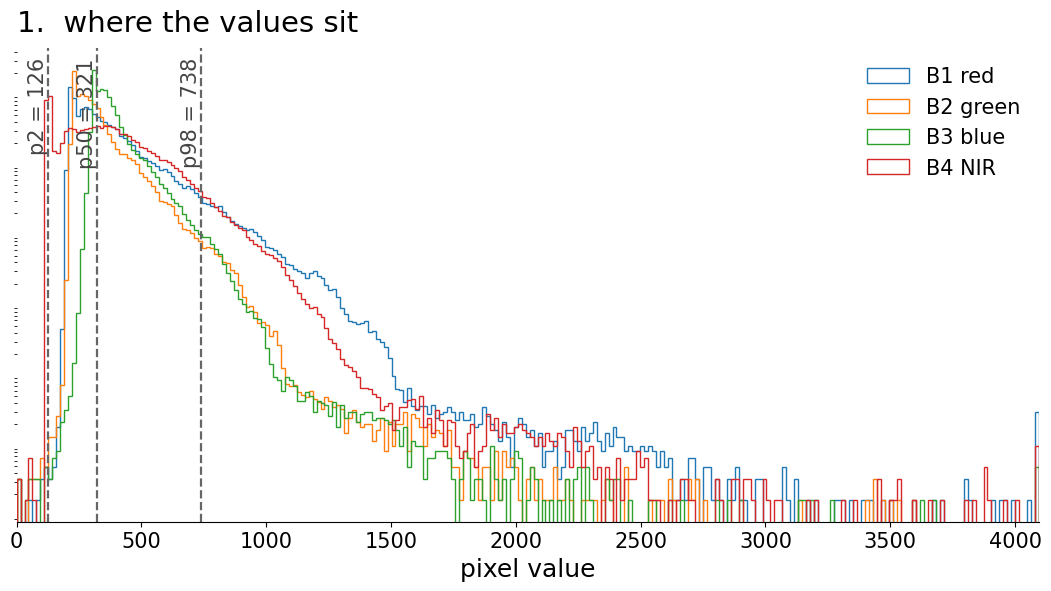

In [3]:
show_distribution(PATH)

## Q2.  How are the bands arranged?


In [4]:
with rasterio.open(PATH) as d:
    print('bands      ', d.count, d.indexes)
    print('names      ', d.descriptions)
    print('colorinterp', tuple(c.name for c in d.colorinterp))

bands       4 (1, 2, 3, 4)
names       (None, None, None, None)
colorinterp ('gray', 'undefined', 'undefined', 'undefined')


No names, and `colorinterp` says `gray` followed by `undefined` three times.  **The
file does not know which band is which.**  That has to come from the product spec — or
from looking.

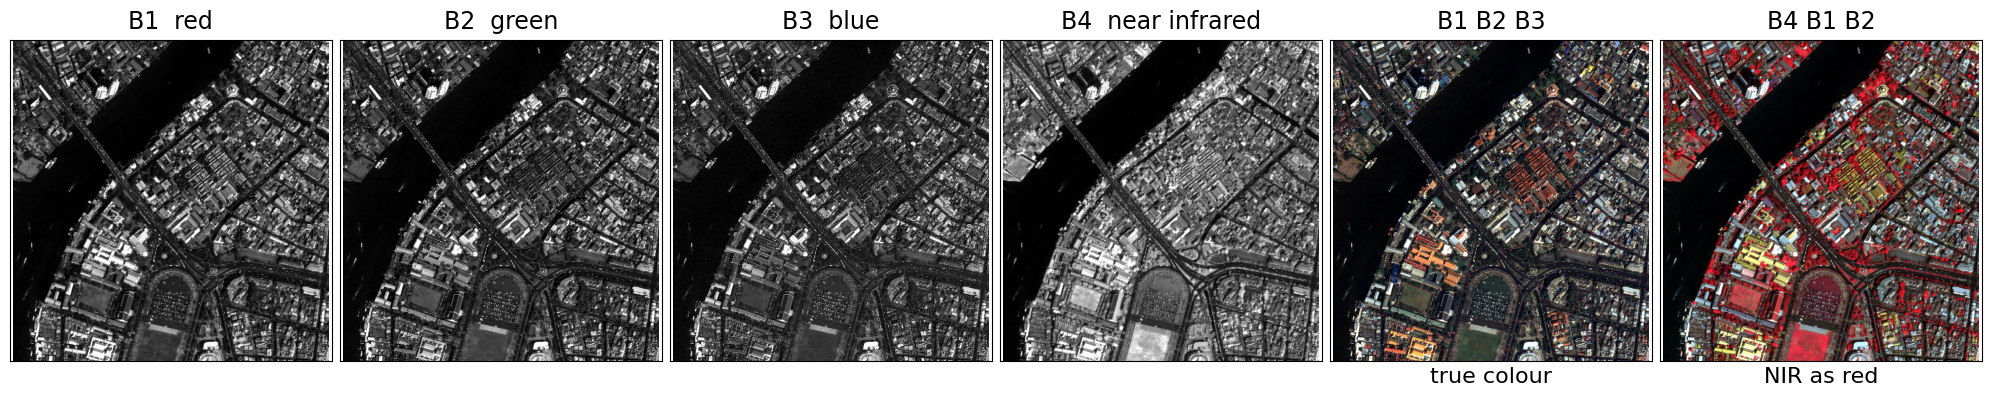

In [5]:
check_bands(PATH)

In the fourth band the river goes black and the parks go bright, which is what water
and vegetation do to near infrared.  So band 4 is NIR and bands 1 - 3 are red, green,
blue.

Getting it wrong raises no error.

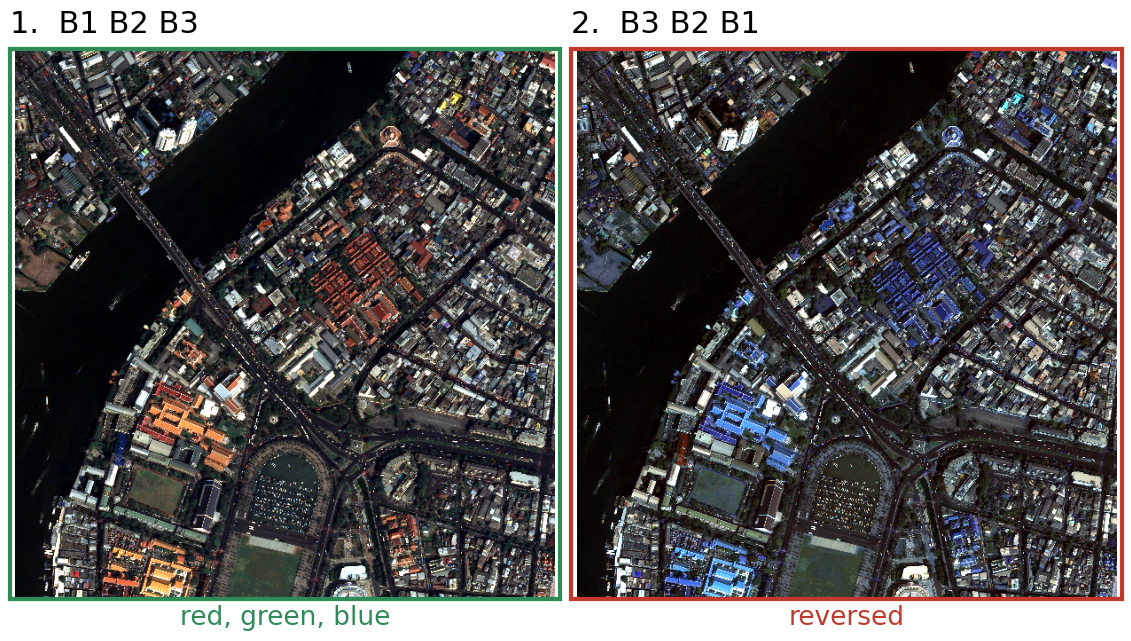

In [6]:
check_order(PATH)

## Q3.  What condition is the scene in?

Cloud and sharpness decide whether the scene is worth processing at all.  Neither needs
a model to spot — two scenes from the same sensor, side by side.

In [7]:
condition([CLEAR, CLOUDY], ['clear', 'cloudy'])

               mean      std     p50     p99    > 900  sharpness
     clear    304.5     95.3     257     695     0.1%     0.0691
    cloudy    823.0    217.1     810    1333    35.0%     0.0137


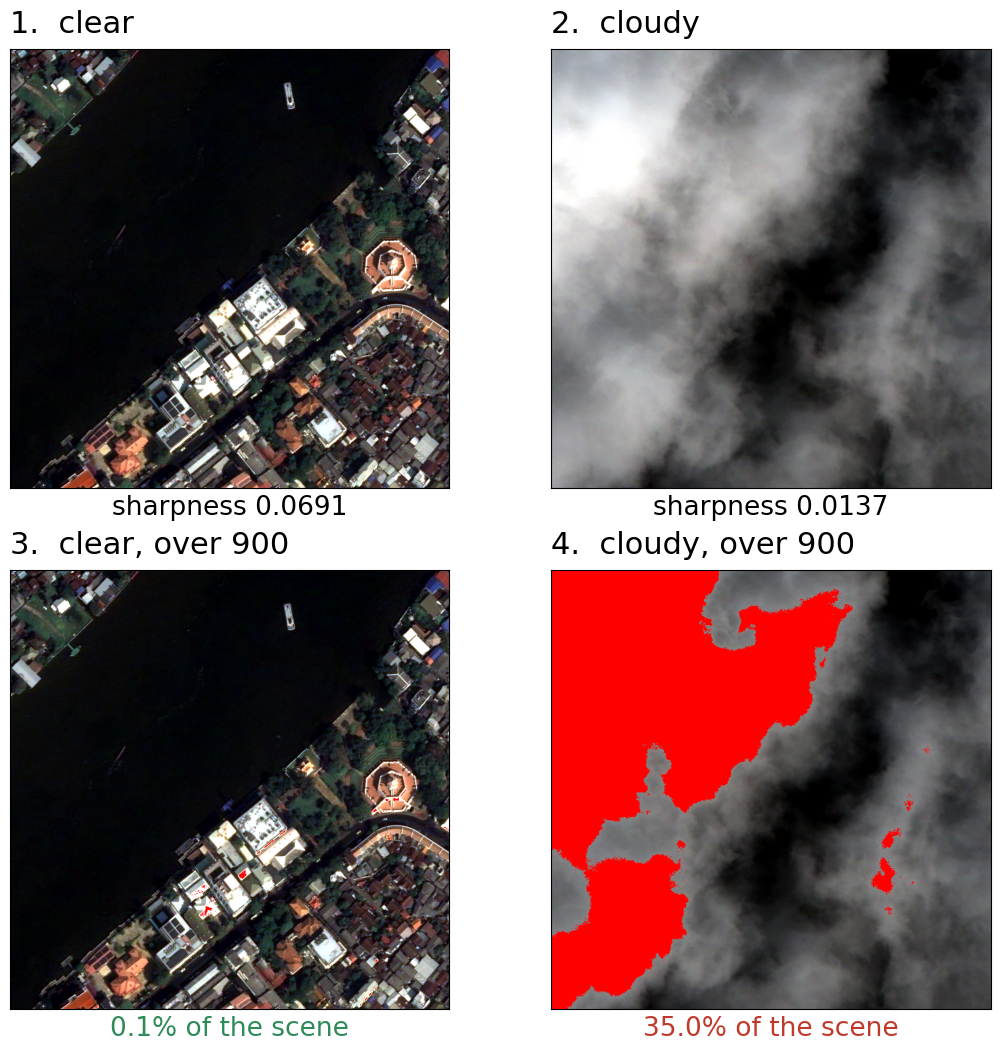

In [8]:
show_condition([CLEAR, CLOUDY], ['clear', 'cloudy'])